# Credit Card Fraud Detection

Detect fraudulent credit card transactions using machine learning techniques designed for highly imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

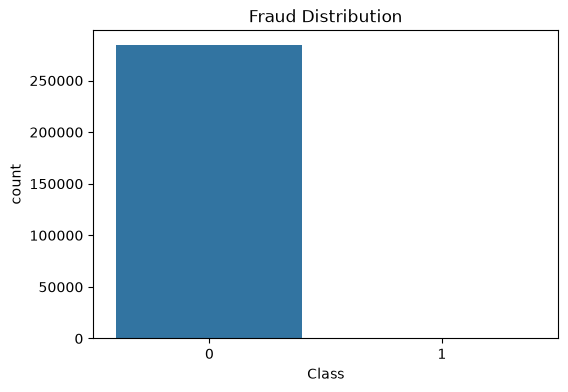

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Class")
plt.title("Fraud Distribution")
plt.show()

## 
Observation:
The dataset is highly imbalanced with very few fraudulent transactions.

## EDA

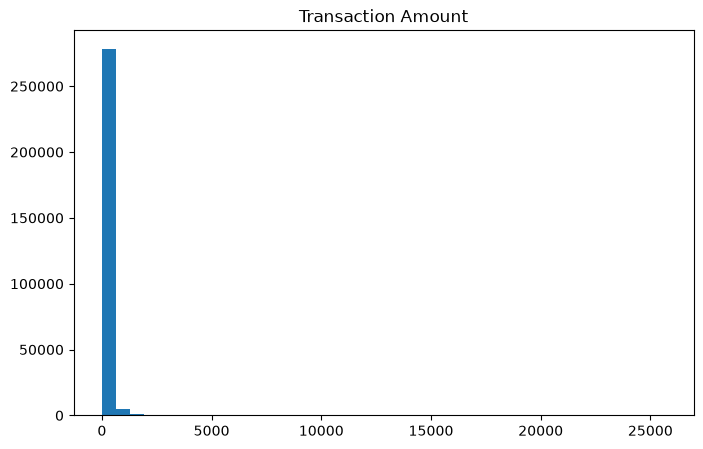

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["Amount"],bins=40)
plt.title("Transaction Amount")
plt.show()

## 
Observation:
Most transactions involve relatively small amounts.

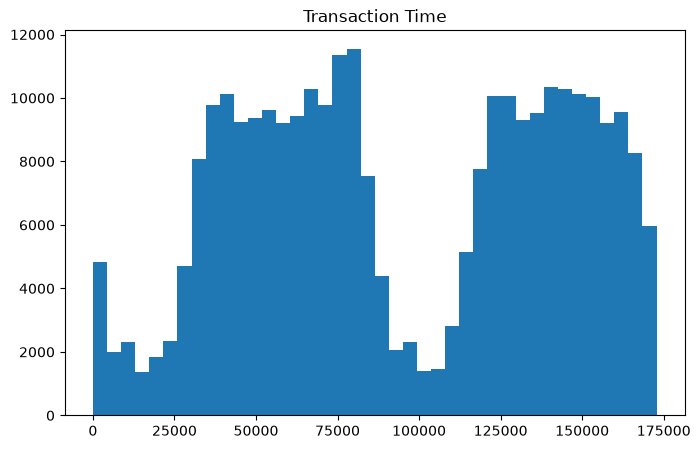

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["Time"],bins=40)
plt.title("Transaction Time")
plt.show()

## 
Observation:
Transactions are spread throughout the recorded time period.

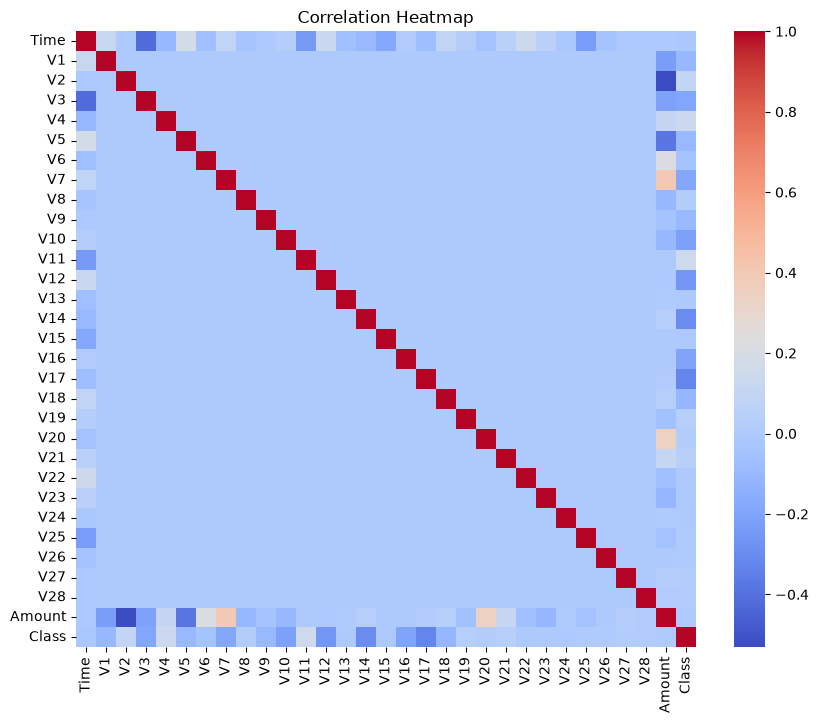

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 
Observation:
Most features are weakly correlated because they are anonymized using PCA.

## Preprocessing

In [9]:
X = df.drop("Class",axis=1)
y = df["Class"]

In [10]:
scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## SMOTE

In [12]:
smote=SMOTE(random_state=42)
X_train,y_train=smote.fit_resample(
    X_train,
    y_train
)

In [13]:
print(y_train.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


## 
Observation:
SMOTE balances the minority class by generating synthetic fraud samples.

## Train Models

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}

In [15]:
results = {}
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    trained_models[name] = model
    print(f"{name} Accuracy: {acc:.4f}\n")

Training Logistic Regression...
Logistic Regression Accuracy: 0.9743

Training Random Forest...
Random Forest Accuracy: 0.9995

Training XGBoost...
XGBoost Accuracy: 0.9971



In [16]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})
results_df

,Model,Accuracy
0,Logistic Regression,0.974264
1,Random Forest,0.999456
2,XGBoost,0.997103


## 
Observation:
Random Forest generally provides the best fraud detection performance.

## Evaluation

In [17]:
best_model = trained_models["Random Forest"]
pred = best_model.predict(X_test)

In [18]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



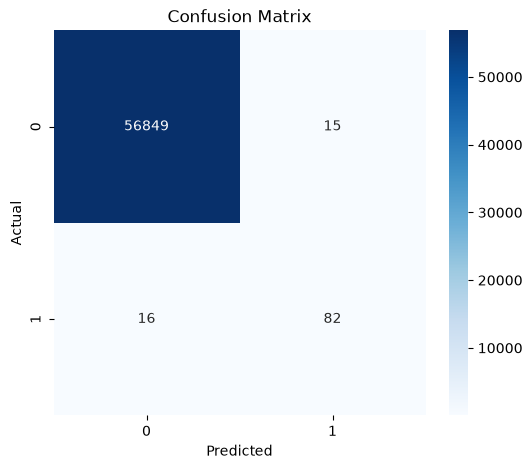

In [19]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
14,V14,0.195592
10,V10,0.110475
4,V4,0.106104
12,V12,0.095099
17,V17,0.085020
3,V3,0.060413
11,V11,0.056353
16,V16,0.043779
2,V2,0.036997
9,V9,0.026209


## 
Observation:
Random Forest achieved the highest accuracy and identified the most influential features for detecting fraudulent transactions.

## Treshold Tuning


In [21]:
prob = best_model.predict_proba(X_test)[:,1]

In [22]:
threshold = 0.30
pred_threshold = (prob >= threshold).astype(int)

In [23]:
print(classification_report(y_test, pred_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.90      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.95      0.90     56962
weighted avg       1.00      1.00      1.00     56962



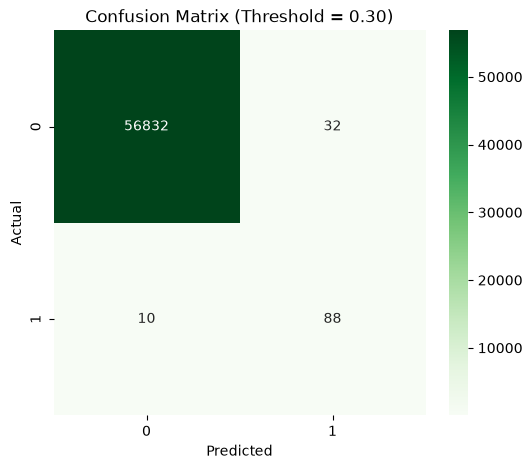

In [24]:
cm = confusion_matrix(y_test, pred_threshold)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Confusion Matrix (Threshold = 0.30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 
Observation:
Reducing the threshold increases the chances of detecting fraudulent transactions but may also increase false positive predictions.

## SHAP

In [28]:
import shap
explainer = shap.TreeExplainer(best_model)

In [29]:
shap_values = explainer.shap_values(X_test.iloc[:1000])

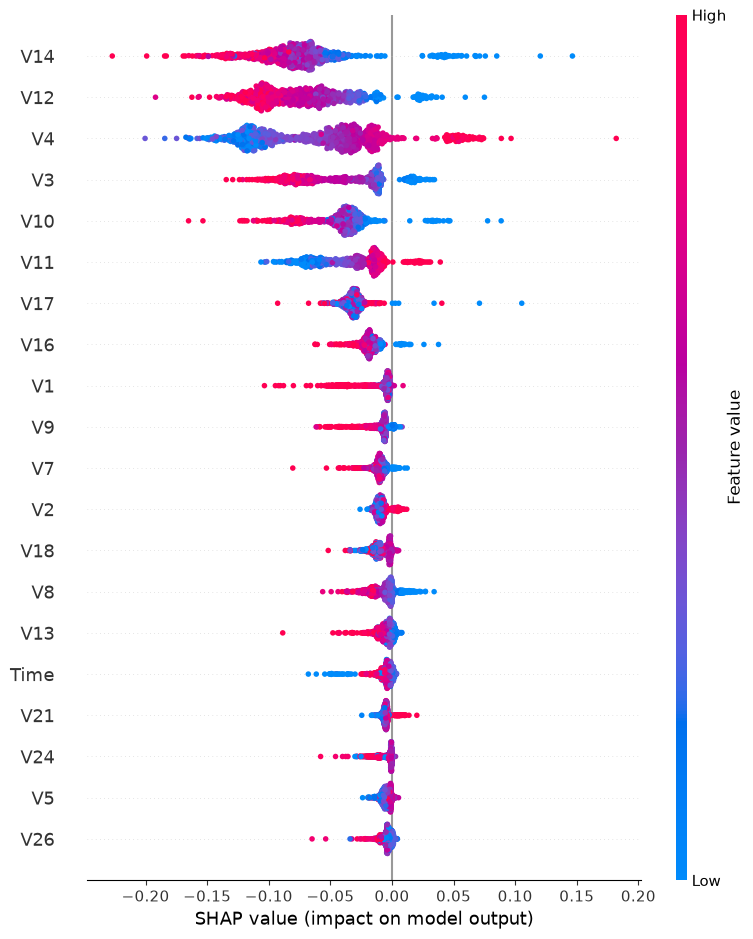

In [38]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test.iloc[:1000]
)

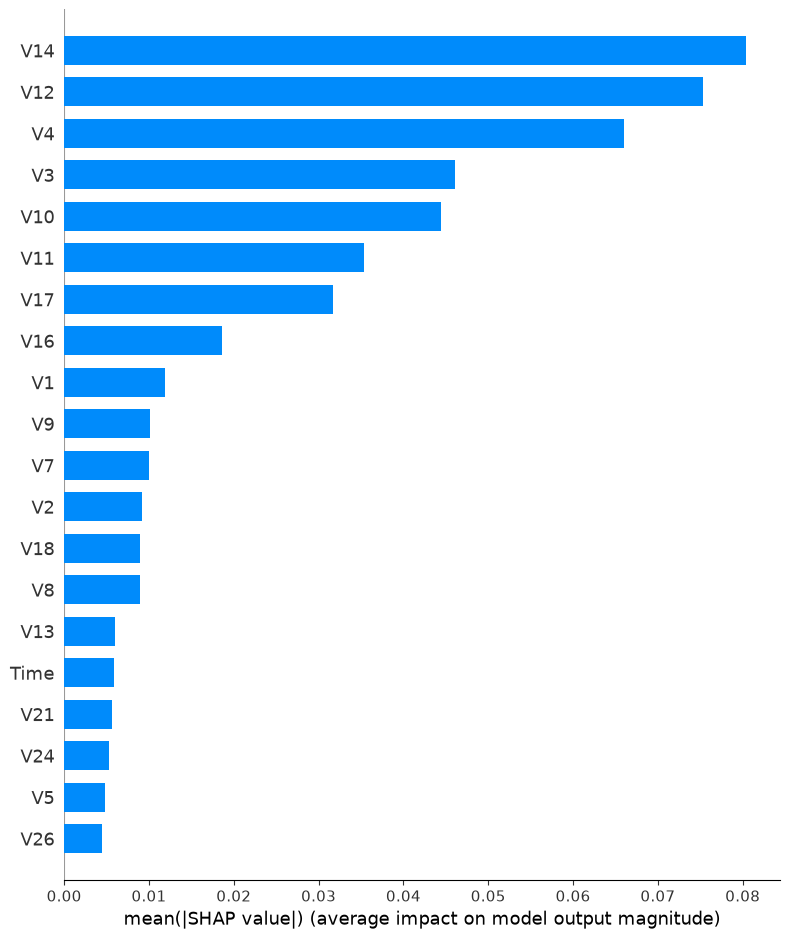

In [39]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test.iloc[:1000],
    plot_type="bar"
)

## 
Observation:
SHAP provides model interpretability by showing how each feature influences fraud predictions. This improves transparency and helps explain the model's decision-making process.

In [42]:
#Saving Outputs
import os
import joblib

os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

In [43]:
joblib.dump(
    trained_models["Random Forest"],
    "../models/fraud_detection_model.pkl"
)
print("Model saved successfully!")

Model saved successfully!


In [44]:
importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [45]:
results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [46]:
print("=" * 50)
print("Credit Card Fraud Detection Project Completed!")
print("=" * 50)

Credit Card Fraud Detection Project Completed!
